In [ ]:
%matplotlib inline

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
print(df.head())
print(df.shape)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)


### Histogram — Understanding the Distribution of Charges

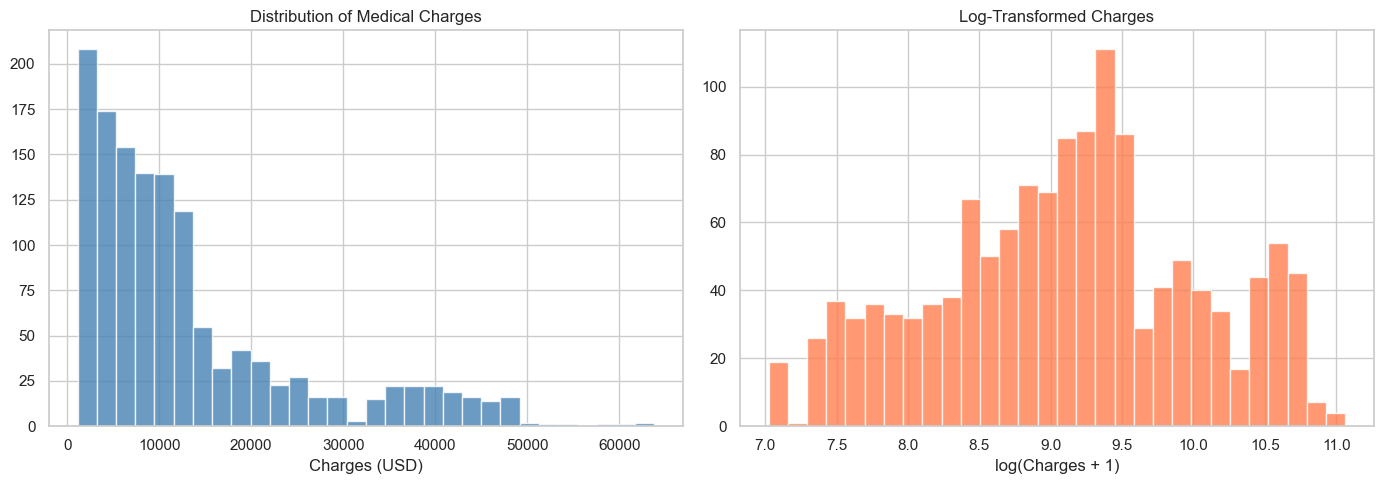

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['charges'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Medical Charges')
axes[0].set_xlabel('Charges (USD)')
axes[1].hist(np.log1p(df['charges']), bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(Charges + 1)')
plt.tight_layout()
plt.show()

#### Observations: Distribution of Medical Charges
- The distribution is **right-skewed**, with most charges concentrated at lower values and a long tail of high charges.  
- Presence of **outliers** is clear — a few individuals have extremely high medical charges compared to the majority.  
- No group differences are visible here since this plot shows overall distribution only.  

#### Observations: Log Transformed Charges
- After log transformation, the distribution becomes **more symmetric**, reducing skewness.  
- Outliers are less extreme and easier to interpret in the transformed scale.  
- Still no group differences shown, but the transformation makes comparisons across individuals more meaningful.  


### KDE Plot — Comparing Groups

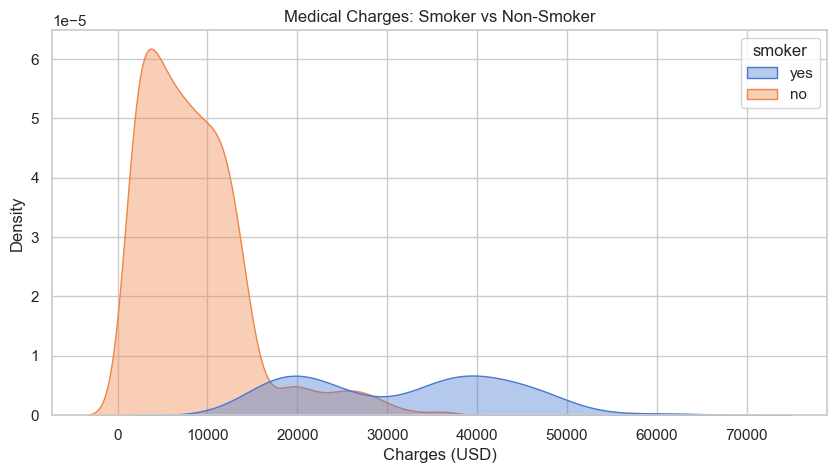

In [11]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='charges', hue='smoker', fill=True, alpha=0.4)
plt.title('Medical Charges: Smoker vs Non-Smoker')
plt.xlabel('Charges (USD)')
plt.show()

### Observations: Medical Charges (Smoker vs Non-Smoker)
- The distribution for **non-smokers** is sharply peaked at lower charges, showing most non-smokers incur relatively low medical costs.  
- The distribution for **smokers** is broader and shifted to the right, indicating higher charges overall and greater variability.  
- Clear **group differences**: smokers tend to have significantly higher medical charges compared to non-smokers.  


### Box Plot — Spotting Outliers 

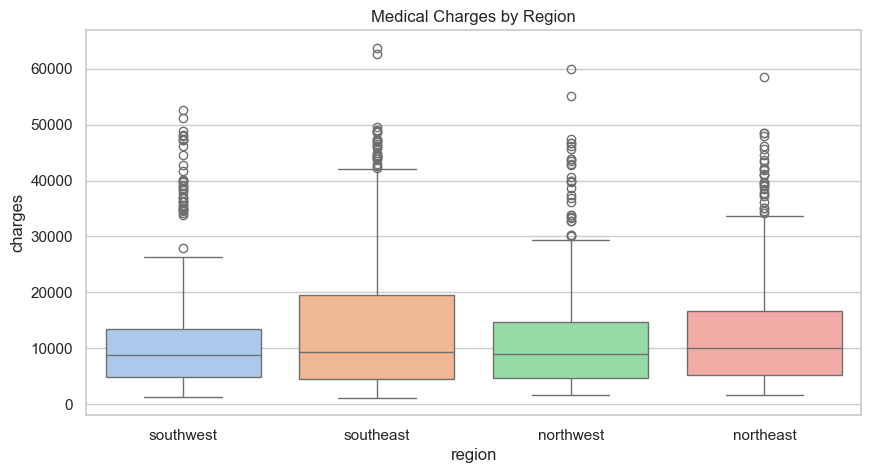

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='region', y='charges', hue='region', palette='pastel', legend=False)
plt.title('Medical Charges by Region')
plt.show()


### Observations: Medical Charges by Region
- The distributions are **right-skewed** across all regions, with most individuals incurring lower charges and a few extreme high-cost cases.  
- Clear **outliers** are present in every region, shown as points far above the boxplots, indicating unusually high medical expenses.  
- **Group differences** are minimal: median charges appear fairly similar across regions, though the Southeast shows slightly higher variability compared to others.  


### Violin Plot — Distribution + Box 

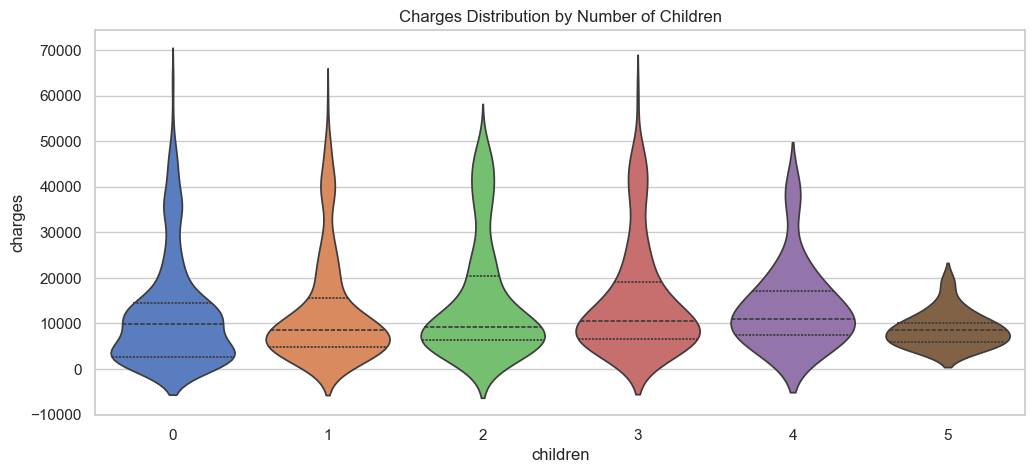

In [17]:
plt.figure(figsize=(12, 5))
sns.violinplot(
    data=df,
    x='children',
    y='charges',
    hue='children',          # explicitly set hue
    palette='muted',
    inner='quartile',
    legend=False             # suppress duplicate legend
)
plt.title('Charges Distribution by Number of Children')
plt.show()


### Observations: Charges Distribution by Number of Children
- The distributions are **right-skewed** across all categories, with most charges concentrated at lower values and a few extreme high-cost cases.  
- **Outliers** are visible in every group, showing individuals with unusually high medical expenses regardless of the number of children.  
- **Group differences** are minimal: the overall spread and median charges look fairly similar across categories, suggesting the number of children does not strongly influence medical charges.  


### Count Plot — Categorical Variables 

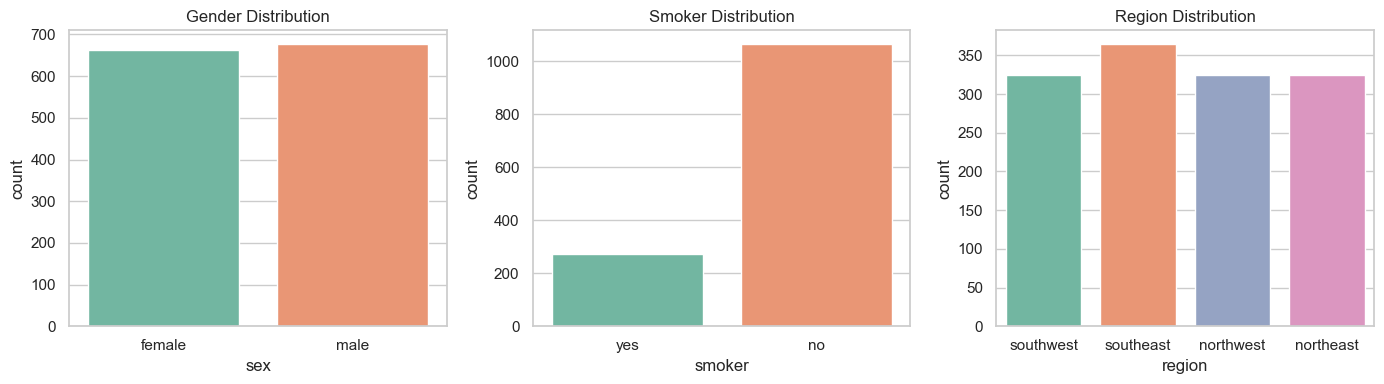

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df, x='sex', hue='sex', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Gender Distribution')

sns.countplot(data=df, x='smoker', hue='smoker', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Smoker Distribution')

sns.countplot(data=df, x='region', hue='region', palette='Set2', legend=False, ax=axes[2])
axes[2].set_title('Region Distribution')

plt.tight_layout()
plt.show()


### Observations: Gender, Smoker, and Region Distributions
- **Gender Distribution**: The dataset is fairly balanced, with nearly equal counts of male and female participants.  
- **Smoker Distribution**: There is a clear imbalance — non-smokers significantly outnumber smokers, which may influence overall charge comparisons.  
- **Region Distribution**: All four regions (southwest, southeast, northwest, northeast) are represented in similar proportions, suggesting no strong sampling bias by geography.  
